In [1]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Tuple, List
import time
import numpy as np
from IPython import display # Jupyter環境用（オプション）

# 環境設定
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)]
DROPOFF_LOCATION = (5, 5)

class WarehouseEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5  # 0:待機, 1:上, 2:下, 3:左, 4:右

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        # 状態の初期化
        self.reset()

    def reset(self) -> Dict[int, Tuple]:
        """環境を初期化し、初期状態を返します。"""
        self.agent_positions: Dict[int, Tuple[int, int]] = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }
        self.agent_holding: Dict[int, bool] = {i: False for i in range(self.num_agents)}
        self.remaining_orders: List[int] = list(range(NUM_ORDERS))
        return self._get_obs()

    def _get_obs(self) -> Dict[int, Tuple]:
        obs = {}
        for i in range(self.num_agents):
            obs[i] = (
                self.agent_positions[i],
                self.agent_holding[i],
                tuple(self.remaining_orders)
            )
        return obs

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, Dict, Dict]:
        next_positions: Dict[int, Tuple[int, int]] = {}
        rewards: Dict[int, float] = {i: -0.1 for i in range(self.num_agents)}

        # 1. 位置の更新
        for i, action in actions.items():
            current_x, current_y = self.agent_positions[i]
            next_x, next_y = current_x, current_y

            if action == 1: next_y += 1  # 上
            elif action == 2: next_y -= 1  # 下
            elif action == 3: next_x -= 1  # 左
            elif action == 4: next_x += 1  # 右

            next_x = np.clip(next_x, 0, self.size - 1)
            next_y = np.clip(next_y, 0, self.size - 1)
            next_positions[i] = (next_x, next_y)

        # 2. 衝突判定
        final_positions = self.agent_positions.copy()
        is_collision = False

        for i in range(self.num_agents):
            pos = next_positions[i]
            is_colliding = False
            for j in range(self.num_agents):
                if i != j and pos == next_positions[j]:
                    is_colliding = True
                    break
            if is_colliding:
                rewards[i] -= 5.0
                is_collision = True
            else:
                final_positions[i] = pos

        self.agent_positions = final_positions

        # 3. ピックアップ・ドロップオフ
        for i in range(self.num_agents):
            current_pos = self.agent_positions[i]
            if not self.agent_holding[i]:
                for order_idx in self.remaining_orders:
                    if current_pos == PICKUP_LOCATIONS[order_idx]:
                        self.agent_holding[i] = True
                        self.remaining_orders.remove(order_idx)
                        rewards[i] += 10.0
                        break
            elif self.agent_holding[i]:
                if current_pos == DROPOFF_LOCATION:
                    self.agent_holding[i] = False
                    rewards[i] += 50.0

        done = {i: len(self.remaining_orders) == 0 for i in range(self.num_agents)}
        return self._get_obs(), rewards, done, {"collision": is_collision}

    # --- 追加された可視化メソッド ---
    def render(self, mode='text', sleep_time=0.5):
        """
        環境を可視化します。
        mode='text': コンソールに文字で表示
        mode='graphic': Matplotlibで図として表示
        """
        if mode == 'text':
            self._render_text()
        elif mode == 'graphic':
            self._render_graphic(sleep_time)

    def _render_text(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]

        # 場所のマーク (y座標は下から上へ増えるため、表示時は反転させるか注意が必要)
        # ここでは (0,0) を左下として扱います
        x, y = DROPOFF_LOCATION
        grid[self.size - 1 - y][x] = 'D'  # Dropoff

        for idx in self.remaining_orders:
            x, y = PICKUP_LOCATIONS[idx]
            grid[self.size - 1 - y][x] = 'P'  # Pickup

        for i, pos in self.agent_positions.items():
            x, y = pos
            char = f'A{i}'
            if self.agent_holding[i]:
                char = f'H{i}' # Holding

            # 同じ場所に重なった場合の表示処理（簡易）
            if grid[self.size - 1 - y][x] not in ['.', 'P', 'D']:
                grid[self.size - 1 - y][x] += char
            else:
                grid[self.size - 1 - y][x] = char

        print("-" * (self.size * 3))
        for row in grid:
            print(" ".join([f"{c:>2}" for c in row]))
        print("-" * (self.size * 3))

    def _render_graphic(self, sleep_time):
        if self.fig is None:
            plt.ion() # インタラクティブモードON
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)
        self.ax.set_xticks(range(self.size))
        self.ax.set_yticks(range(self.size))
        self.ax.grid(True)
        self.ax.set_title(f"Orders Remaining: {len(self.remaining_orders)}")

        # ドロップオフ地点 (赤色)
        dx, dy = DROPOFF_LOCATION
        self.ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3, label='Dropoff'))
        self.ax.text(dx, dy, 'Drop', ha='center', va='center', fontsize=8, color='darkred')

        # ピックアップ地点 (青色)
        for idx in self.remaining_orders:
            px, py = PICKUP_LOCATIONS[idx]
            self.ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color='blue', alpha=0.3, label='Pickup'))
            self.ax.text(px, py, 'Pick', ha='center', va='center', fontsize=8, color='darkblue')

        # エージェント (円)
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, pos in self.agent_positions.items():
            ax, ay = pos
            color = colors[i % len(colors)]
            # 荷物を持っている場合は枠線を太く、色を変えるなどの表現
            edgecolor = 'black'
            linewidth = 1
            if self.agent_holding[i]:
                linewidth = 3
                edgecolor = 'red' # 荷物持ち強調

            circle = patches.Circle((ax, ay), 0.3, facecolor=color, edgecolor=edgecolor, linewidth=linewidth, label=f'Agent {i}')
            self.ax.add_patch(circle)
            self.ax.text(ax, ay, f'A{i}', ha='center', va='center', color='white', fontweight='bold')

        plt.draw()
        plt.pause(sleep_time)



In [ ]:
# 'graphic' モードを使用する場合は、GUI環境が必要です。
# Google Colabなどで動かす場合は少し工夫が必要ですが、ローカル環境ならウィンドウが開きます。

env = WarehouseEnv()
obs = env.reset()

print("--- グラフィカル描画を開始します ---")

for t in range(20): # 20ステップ実行
    # ランダムに行動決定
    actions = {i: random.randint(0, 4) for i in range(env.num_agents)}

    obs, rewards, done, info = env.step(actions)

    # ここで可視化 (graphic または text)
    env.render(mode='graphic', sleep_time=0.2)
    # env.render(mode='text') # コンソールで見たい場合

    if all(done.values()):
        print("全てのタスク完了！")
        # 最後に少し待機
        plt.pause(2.0)
        break

print("終了")
plt.ioff()
plt.show() # 最後の画面を残す

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List
import time
# WarehouseEnv は前のコードから引き継がれます

# --- ハイパーパラメータ ---
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 5000
TARGET_UPDATE = 100
LR_AGENT = 0.0005
LR_MIXER = 0.001
MEMORY_SIZE = 50000
NUM_EPISODES = 10000
MAX_STEPS = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3

# 状態空間サイズを計算 (位置10x10 + 荷物有無2 + 残りオーダー数2^3=8ではないが、今回はタプルそのまま)
# 単純化のため、状態は (位置X, 位置Y, 荷物有無, オーダービットマスク) のタプルから変換します。
STATE_DIM = GRID_SIZE * GRID_SIZE + 1 + (2**NUM_ORDERS) # ざっくりとした最大値

# ----------------------------------------------------
# 1. ネットワーク定義
# ----------------------------------------------------

class AgentNet(nn.Module):
    """
    各エージェントの局所Q値を計算するネットワーク
    """
    def __init__(self, input_dim, output_dim):
        super(AgentNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class QMixer(nn.Module):
    """
    エージェントのQ値を結合してQ_totを計算するミキシングネットワーク
    モノトニック制約（単調増加）のため、重みは非負にする。
    """
    def __init__(self, num_agents, state_dim, hidden_dim):
        super(QMixer, self).__init__()
        self.num_agents = num_agents
        self.state_dim = state_dim

        # 重みネットワーク (W1: state -> hidden_dim * num_agents)
        self.hyper_w1 = nn.Linear(state_dim, hidden_dim * num_agents)
        # バイアスネットワーク (B1: state -> hidden_dim)
        self.hyper_b1 = nn.Linear(state_dim, hidden_dim)

        # 重みネットワーク (W2: state -> hidden_dim)
        self.hyper_w2 = nn.Linear(state_dim, hidden_dim)
        # バイアス (B2: state -> 1)
        self.hyper_b2 = nn.Linear(state_dim, 1)

        self.hidden_dim = hidden_dim

    def forward(self, agent_qs, states):
        # agent_qs: (batch_size, num_agents, 1)
        # states: (batch_size, state_dim)
        batch_size = agent_qs.size(0)

        # --- W1 の計算 ---
        # W1 = tanh(hyper_w1(states)) * |hyper_w1| の代わり
        w1 = torch.abs(self.hyper_w1(states)) # モノトニック制約: 重みを非負にする
        w1 = w1.view(batch_size, self.num_agents, self.hidden_dim) # (B, N, H)

        # --- Q * W1 の計算 ---
        # agent_qs: (B, N, 1) -> (B, N, H) に拡張
        agent_qs = agent_qs.view(batch_size, self.num_agents, 1)

        # 結合 (Q * W1)
        hidden = torch.bmm(agent_qs.transpose(1, 2), w1) # (B, 1, N) x (B, N, H) -> (B, 1, H)

        # --- B1 の計算 ---
        b1 = self.hyper_b1(states) # (B, H)
        b1 = b1.view(batch_size, 1, self.hidden_dim) # (B, 1, H)

        hidden = F.relu(hidden + b1) # (B, 1, H)

        # --- W2 の計算 ---
        w2 = torch.abs(self.hyper_w2(states)) # モノトニック制約
        w2 = w2.view(batch_size, self.hidden_dim, 1) # (B, H, 1)

        # --- (Q * W1 + B1) * W2 + B2 の計算 ---
        q_tot = torch.bmm(hidden, w2) # (B, 1, H) x (B, H, 1) -> (B, 1, 1)

        b2 = self.hyper_b2(states) # (B, 1)
        b2 = b2.view(batch_size, 1, 1) # (B, 1, 1)

        q_tot = q_tot.view(batch_size, 1) + b2.view(batch_size, 1) # (B, 1)

        return q_tot.squeeze(-1) # (B,)


# ----------------------------------------------------
# 2. Replay Memory (バッチのTensor化処理を強化)
# ----------------------------------------------------

class QMixReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        # state: Dict[int, Tuple]
        # action: Dict[int, int]
        # next_state: Dict[int, Tuple]
        # reward: Dict[int, float]
        # done: bool
        self.memory.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# ----------------------------------------------------
# 3. QMIXエージェントクラス
# ----------------------------------------------------

class QMixAgent:
    def __init__(self, env: 'WarehouseEnv', state_dim):
        self.env = env
        self.num_agents = env.num_agents
        self.action_space = env.action_space
        self.state_dim = state_dim

        # Policy Networks
        self.agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                         for _ in range(self.num_agents)])
        self.mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)

        # Target Networks
        self.target_agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                                for _ in range(self.num_agents)])
        self.target_mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)
        self.update_target_networks()

        # Optimizers
        self.optimizer_agents = optim.Adam(self._get_agent_params(), lr=LR_AGENT)
        self.optimizer_mixer = optim.Adam(self.mixer.parameters(), lr=LR_MIXER)

        self.memory = QMixReplayMemory(MEMORY_SIZE)
        self.steps_done = 0

    def _get_agent_input_dim(self):
        # (位置X, 位置Y, 荷物有無, 残りオーダー数)
        return 2 + 1 + NUM_ORDERS # (10, 10)をそのまま2次元、荷物有無1次元、残りオーダーを3次元のフラグで表現

    def _get_agent_params(self):
        params = []
        for net in self.agent_nets:
            params.extend(list(net.parameters()))
        return params

    def preprocess_state(self, obs: Dict[int, Tuple]):
        """
        環境の状態 (タプル) を学習可能なTensorに変換
        グローバル状態 (ミキサー用) とローカル状態 (エージェントネット用) を作成
        """
        # グローバル状態 (Global State): 全エージェントの位置、荷物有無、残りオーダー
        # (2*N + N + NUM_ORDERS)
        global_state = []
        for i in range(self.num_agents):
            (px, py), holding, _ = obs[i]
            global_state.extend([px / (self.env.size - 1), py / (self.env.size - 1), float(holding)])

        # 残りオーダー (ビットマスクをフラグに変換)
        order_mask = [0.0] * NUM_ORDERS
        remaining_order_ids = obs[0][2] # エージェント0から残りのオーダー情報 (タプル) を取得
        for order_id in remaining_order_ids:
            order_mask[order_id] = 1.0
        global_state.extend(order_mask)

        global_state_tensor = torch.tensor([global_state], dtype=torch.float32, device=device)

        # ローカル状態 (Agent State):
        local_states = []
        for i in range(self.num_agents):
            (px, py), holding, remaining_orders_tuple = obs[i]

            # ローカル入力 (位置, 荷物, オーダーマスク)
            local_input = [px / (self.env.size - 1), py / (self.env.size - 1), float(holding)]

            # ローカルもグローバルと同じオーダーマスク情報を持つ
            local_input.extend(order_mask)

            local_states.append(torch.tensor([local_input], dtype=torch.float32, device=device))

        return global_state_tensor, local_states

    def select_action(self, global_state_tensor, local_states: List[torch.Tensor]):
        """
        ε-greedy法に基づく行動選択
        """
        sample = random.random()
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
            np.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1

        actions = {}
        if sample > eps_threshold:
            with torch.no_grad():
                for i in range(self.num_agents):
                    # AgentNetからQ値を計算し、最大の行動を選択
                    q_values = self.agent_nets[i](local_states[i])
                    action = q_values.max(1)[1].item()
                    actions[i] = action
        else:
            # ランダム行動
            actions = {i: random.randrange(self.action_space) for i in range(self.num_agents)}

        return actions

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        transitions = self.memory.sample(BATCH_SIZE)

        # 1. バッチデータの処理とTensor化
        # QMIXでは、グローバル状態、エージェント行動、エージェント報酬をまとめて処理

        batch_global_state = []
        batch_local_states = [] # N x (B, InputDim)
        batch_next_global_state = []
        batch_actions = []
        batch_rewards = []
        batch_done = []

        for state_dict, action_dict, next_state_dict, reward_dict, done_bool in transitions:
            # グローバル状態のテンソル化（ここで前処理を再実行）
            global_state, local_states = self.preprocess_state(state_dict)
            next_global_state, next_local_states = self.preprocess_state(next_state_dict)

            batch_global_state.append(global_state.squeeze(0))
            batch_next_global_state.append(next_global_state.squeeze(0))

            # ローカル状態をエージェントごとにリストに追加
            if not batch_local_states:
                batch_local_states = [[] for _ in range(self.num_agents)]
            for i in range(self.num_agents):
                batch_local_states[i].append(local_states[i].squeeze(0))

            # 行動と報酬
            batch_actions.append([action_dict[i] for i in range(self.num_agents)])
            # QMIXではチーム報酬 (Total reward) を使用
            batch_rewards.append(sum(reward_dict.values()))
            batch_done.append(float(done_bool))

        # Tensorに変換
        global_state_batch = torch.stack(batch_global_state).to(device) # (B, StateDim)
        next_global_state_batch = torch.stack(batch_next_global_state).to(device) # (B, StateDim)

        local_states_batch = [torch.stack(l).to(device) for l in batch_local_states] # N x (B, InputDim)

        action_batch = torch.tensor(batch_actions, dtype=torch.long, device=device) # (B, N)
        reward_batch = torch.tensor(batch_rewards, dtype=torch.float32, device=device).unsqueeze(1) # (B, 1)
        done_batch = torch.tensor(batch_done, dtype=torch.float32, device=device).unsqueeze(1) # (B, 1)

        # 2. Q(s, a) の計算 (Policy Net)

        q_values_list = []
        for i in range(self.num_agents):
            # Q値の計算 (B, ActionSpace)
            q_all = self.agent_nets[i](local_states_batch[i])
            # 実行された行動に対応するQ値を取得 (B, 1)
            q_selected = q_all.gather(1, action_batch[:, i].unsqueeze(1))
            q_values_list.append(q_selected)

        # 各エージェントのQ値をスタック (B, N, 1)
        q_selected_agents = torch.stack(q_values_list, dim=1)
        # Mixerでチーム全体のQ値を計算 (B, 1)
        q_tot = self.mixer(q_selected_agents, global_state_batch).unsqueeze(1) # (B, 1)

        # 3. ターゲット値の計算 (Target Net)

        # Target Agent Netで次状態のQ値を計算
        target_q_values_list = []
        for i in range(self.num_agents):
            with torch.no_grad():
                target_q_all = self.target_agent_nets[i](next_local_states[i])
                target_q_values_list.append(target_q_all)

        # **DQNと同様、ターゲットQ値は最大行動を選択 (貪欲)**
        # 各エージェントで最適な行動に対応するQ値を取得 (B, 1)
        target_q_selected_agents = torch.stack([q.max(1)[0].detach().unsqueeze(1)
                                                for q in target_q_values_list], dim=1) # (B, N, 1)

        # Target Mixerでチーム全体のQ'を計算
        with torch.no_grad():
            q_next_tot = self.target_mixer(target_q_selected_agents, next_global_state_batch).unsqueeze(1) # (B, 1)

        # ターゲット値の計算: R + γ * Q_next_tot * (1 - done)
        expected_q_tot = reward_batch + GAMMA * q_next_tot * (1 - done_batch)

        # 4. 損失計算と最適化

        criterion = nn.SmoothL1Loss()
        loss = criterion(q_tot, expected_q_tot)

        self.optimizer_agents.zero_grad()
        self.optimizer_mixer.zero_grad()
        loss.backward()

        # 勾配クリッピング
        for param in self._get_agent_params():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)
        for param in self.mixer.parameters():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)

        self.optimizer_agents.step()
        self.optimizer_mixer.step()

        return loss.item()

    def update_target_networks(self):
        # Target Agent Nets
        for policy_net, target_net in zip(self.agent_nets, self.target_agent_nets):
            target_net.load_state_dict(policy_net.state_dict())
        # Target Mixer
        self.target_mixer.load_state_dict(self.mixer.state_dict())


# ----------------------------------------------------
# 4. 学習ループ
# ----------------------------------------------------

def train_qmix_agent(env: 'WarehouseEnv'):

    # グローバル状態の次元を再計算（QMixAgent.__init__内と同じロジック）
    state_dim = 2 * env.num_agents + env.num_agents + NUM_ORDERS # (位置 + 荷物 + オーダーマスク)
    agent = QMixAgent(env, state_dim=state_dim)

    rewards_history = []

    print("--- QMIX 学習開始 ---")

    for i_episode in range(NUM_EPISODES):
        obs = env.reset()
        global_state, local_states = agent.preprocess_state(obs)

        episode_reward = 0

        for t in range(MAX_STEPS):
            # 1. 行動決定
            actions = agent.select_action(global_state, local_states)

            # 2. 環境実行
            next_obs, rewards, done, info = env.step(actions)

            # 3. 経験の保存
            # next_obsは次の状態のdict
            agent.memory.push(obs, actions, next_obs, rewards, all(done.values()))

            # 4. 状態更新と報酬集計
            obs = next_obs
            global_state, local_states = agent.preprocess_state(obs)
            episode_reward += sum(rewards.values())

            # 5. モデルの最適化
            loss = agent.optimize_model()

            if all(done.values()):
                break

        rewards_history.append(episode_reward)

        # ターゲットネットワークの定期更新
        if (i_episode + 1) % TARGET_UPDATE == 0:
            agent.update_target_networks()

        # ログ出力
        if (i_episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episode {i_episode+1}/{NUM_EPISODES} | Avg Reward (100): {avg_reward:.2f} | Steps: {t+1}")

    print("\n✅ 学習完了")
    return agent, rewards_history


# ----------------------------------------------------
# 5. 実行とテスト
# ----------------------------------------------------

if __name__ == "__main__":
    env = WarehouseEnv(size=GRID_SIZE, num_agents=NUM_AGENTS)

    # 学習の実行
    trained_agent, rewards = train_qmix_agent(env)

    # 学習曲線の表示
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title("QMIX Total Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    # --- 学習済みモデルでのテスト実行 ---
    print("\n--- テスト実行 (可視化) ---")
    obs = env.reset()
    trained_agent.agent_nets.eval() # 評価モード

    for t in range(MAX_STEPS):
        global_state, local_states = trained_agent.preprocess_state(obs)

        # ε=0 (貪欲) で行動を選択
        actions = {}
        with torch.no_grad():
            for i in range(env.num_agents):
                q_values = trained_agent.agent_nets[i](local_states[i])
                action = q_values.max(1)[1].item()
                actions[i] = action

        next_obs, rewards, done, info = env.step(actions)

        # 可視化
        env.render(mode='graphic', sleep_time=0.1)

        obs = next_obs

        if all(done.values()):
            print(f"テスト完了！ 全てのタスクを {t+1} ステップで完了しました。")
            plt.pause(2.0)
            break

    plt.ioff()
    plt.show()

--- QMIX 学習開始 ---


RuntimeError: shape '[1, 2, 32]' is invalid for input of size 4096

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List
import time
# WarehouseEnv は前のコードから引き継がれます

# --- ハイパーパラメータ ---
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 5000
TARGET_UPDATE = 100
LR_AGENT = 0.0005
LR_MIXER = 0.001
MEMORY_SIZE = 50000
NUM_EPISODES = 10000
MAX_STEPS = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3

# 🚨 修正箇所 1: 誤ったグローバル STATE_DIM の定義を削除/コメントアウト 🚨
# STATE_DIM = GRID_SIZE * GRID_SIZE + 1 + (2**NUM_ORDERS) # 削除またはコメントアウト

# ----------------------------------------------------
# 1. ネットワーク定義
# ----------------------------------------------------

class AgentNet(nn.Module):
    """
    各エージェントの局所Q値を計算するネットワーク
    """
    def __init__(self, input_dim, output_dim):
        super(AgentNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


class QMixer(nn.Module):
    """
    エージェントのQ値を結合してQ_totを計算するミキシングネットワーク
    モノトニック制約（単調増加）のため、重みは非負にする。
    """
    def __init__(self, num_agents, state_dim, hidden_dim):
        super(QMixer, self).__init__()
        self.num_agents = num_agents
        self.state_dim = state_dim

        # 重みネットワーク (W1: state_dim -> hidden_dim * num_agents)
        self.hyper_w1 = nn.Linear(state_dim, hidden_dim * num_agents)
        # バイアスネットワーク (B1: state_dim -> hidden_dim)
        self.hyper_b1 = nn.Linear(state_dim, hidden_dim)

        # 重みネットワーク (W2: state_dim -> hidden_dim)
        self.hyper_w2 = nn.Linear(state_dim, hidden_dim)
        # バイアス (B2: state_dim -> 1)
        self.hyper_b2 = nn.Linear(state_dim, 1)

        self.hidden_dim = hidden_dim

    def forward(self, agent_qs, states):
        # agent_qs: (batch_size, num_agents, 1)
        # states: (batch_size, state_dim)
        batch_size = agent_qs.size(0)

        # --- W1 の計算 ---
        w1 = torch.abs(self.hyper_w1(states)) # モノトニック制約: 重みを非負にする
        # w1 の形状は (B, num_agents * hidden_dim) = (B, 64) となるはず
        w1 = w1.view(batch_size, self.num_agents, self.hidden_dim) # (B, N, H)

        # --- Q * W1 の計算 ---
        agent_qs = agent_qs.view(batch_size, self.num_agents, 1)

        # 結合 (Q * W1)
        hidden = torch.bmm(agent_qs.transpose(1, 2), w1) # (B, 1, N) x (B, N, H) -> (B, 1, H)

        # --- B1 の計算 ---
        b1 = self.hyper_b1(states) # (B, H)
        b1 = b1.view(batch_size, 1, self.hidden_dim) # (B, 1, H)

        hidden = F.relu(hidden + b1) # (B, 1, H)

        # --- W2 の計算 ---
        w2 = torch.abs(self.hyper_w2(states)) # モノトニック制約
        w2 = w2.view(batch_size, self.hidden_dim, 1) # (B, H, 1)

        # --- (Q * W1 + B1) * W2 + B2 の計算 ---
        q_tot = torch.bmm(hidden, w2) # (B, 1, H) x (B, H, 1) -> (B, 1, 1)

        b2 = self.hyper_b2(states) # (B, 1)
        b2 = b2.view(batch_size, 1, 1) # (B, 1, 1)

        q_tot = q_tot.view(batch_size, 1) + b2.view(batch_size, 1) # (B, 1)

        return q_tot.squeeze(-1) # (B,)


# ----------------------------------------------------
# 2. Replay Memory (変更なし)
# ----------------------------------------------------

class QMixReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        self.memory.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# ----------------------------------------------------
# 3. QMIXエージェントクラス (変更なし)
# ----------------------------------------------------

class QMixAgent:
    def __init__(self, env: 'WarehouseEnv', state_dim):
        self.env = env
        self.num_agents = env.num_agents
        self.action_space = env.action_space
        self.state_dim = state_dim

        # Policy Networks
        self.agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                         for _ in range(self.num_agents)])
        self.mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)

        # Target Networks
        self.target_agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                                for _ in range(self.num_agents)])
        self.target_mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)
        self.update_target_networks()

        # Optimizers
        self.optimizer_agents = optim.Adam(self._get_agent_params(), lr=LR_AGENT)
        self.optimizer_mixer = optim.Adam(self.mixer.parameters(), lr=LR_MIXER)

        self.memory = QMixReplayMemory(MEMORY_SIZE)
        self.steps_done = 0

    def _get_agent_input_dim(self):
        # (位置X, 位置Y, 荷物有無, 残りオーダー数)
        return 2 + 1 + NUM_ORDERS

    def _get_agent_params(self):
        params = []
        for net in self.agent_nets:
            params.extend(list(net.parameters()))
        return params

    def preprocess_state(self, obs: Dict[int, Tuple]):
        """
        環境の状態 (タプル) を学習可能なTensorに変換
        グローバル状態 (ミキサー用) とローカル状態 (エージェントネット用) を作成
        """
        global_state = []
        for i in range(self.num_agents):
            (px, py), holding, _ = obs[i]
            global_state.extend([px / (self.env.size - 1), py / (self.env.size - 1), float(holding)])

        order_mask = [0.0] * NUM_ORDERS
        remaining_order_ids = obs[0][2]
        for order_id in remaining_order_ids:
            order_mask[order_id] = 1.0
        global_state.extend(order_mask)

        global_state_tensor = torch.tensor([global_state], dtype=torch.float32, device=device)

        local_states = []
        for i in range(self.num_agents):
            (px, py), holding, remaining_orders_tuple = obs[i]

            local_input = [px / (self.env.size - 1), py / (self.env.size - 1), float(holding)]
            local_input.extend(order_mask)

            local_states.append(torch.tensor([local_input], dtype=torch.float32, device=device))

        return global_state_tensor, local_states

    def select_action(self, global_state_tensor, local_states: List[torch.Tensor]):
        sample = random.random()
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
            np.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1

        actions = {}
        if sample > eps_threshold:
            with torch.no_grad():
                for i in range(self.num_agents):
                    q_values = self.agent_nets[i](local_states[i])
                    action = q_values.max(1)[1].item()
                    actions[i] = action
        else:
            actions = {i: random.randrange(self.action_space) for i in range(self.num_agents)}

        return actions

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return

        transitions = self.memory.sample(BATCH_SIZE)

        # 1. バッチデータの処理とTensor化
        batch_global_state = []
        batch_local_states = [[] for _ in range(self.num_agents)] # N x (B, InputDim)
        batch_next_global_state = []
        batch_actions = []
        batch_rewards = []
        batch_done = []

        for state_dict, action_dict, next_state_dict, reward_dict, done_bool in transitions:
            global_state, local_states = self.preprocess_state(state_dict)
            next_global_state, next_local_states = self.preprocess_state(next_state_dict)

            batch_global_state.append(global_state.squeeze(0))
            batch_next_global_state.append(next_global_state.squeeze(0))

            for i in range(self.num_agents):
                batch_local_states[i].append(local_states[i].squeeze(0))

            batch_actions.append([action_dict[i] for i in range(self.num_agents)])
            batch_rewards.append(sum(reward_dict.values()))
            batch_done.append(float(done_bool))

        global_state_batch = torch.stack(batch_global_state).to(device) # (B, StateDim)
        next_global_state_batch = torch.stack(batch_next_global_state).to(device) # (B, StateDim)

        local_states_batch = [torch.stack(l).to(device) for l in batch_local_states] # N x (B, InputDim)

        action_batch = torch.tensor(batch_actions, dtype=torch.long, device=device) # (B, N)
        reward_batch = torch.tensor(batch_rewards, dtype=torch.float32, device=device).unsqueeze(1) # (B, 1)
        done_batch = torch.tensor(batch_done, dtype=torch.float32, device=device).unsqueeze(1) # (B, 1)

        # 2. Q(s, a) の計算 (Policy Net)
        q_values_list = []
        for i in range(self.num_agents):
            q_all = self.agent_nets[i](local_states_batch[i])
            q_selected = q_all.gather(1, action_batch[:, i].unsqueeze(1))
            q_values_list.append(q_selected)

        q_selected_agents = torch.stack(q_values_list, dim=1)
        q_tot = self.mixer(q_selected_agents, global_state_batch).unsqueeze(1) # (B, 1)

        # 3. ターゲット値の計算 (Target Net)
        target_q_values_list = []
        for i in range(self.num_agents):
            with torch.no_grad():
                target_q_all = self.target_agent_nets[i](next_local_states[i])
                target_q_values_list.append(target_q_all)

        target_q_selected_agents = torch.stack([q.max(1)[0].detach().unsqueeze(1)
                                                 for q in target_q_values_list], dim=1) # (B, N, 1)

        with torch.no_grad():
            q_next_tot = self.target_mixer(target_q_selected_agents, next_global_state_batch).unsqueeze(1) # (B, 1)

        expected_q_tot = reward_batch + GAMMA * q_next_tot * (1 - done_batch)

        # 4. 損失計算と最適化
        criterion = nn.SmoothL1Loss()
        loss = criterion(q_tot, expected_q_tot)

        self.optimizer_agents.zero_grad()
        self.optimizer_mixer.zero_grad()
        loss.backward()

        # 勾配クリッピング
        for param in self._get_agent_params():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)
        for param in self.mixer.parameters():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)

        self.optimizer_agents.step()
        self.optimizer_mixer.step()

        return loss.item()

    def update_target_networks(self):
        for policy_net, target_net in zip(self.agent_nets, self.target_agent_nets):
            target_net.load_state_dict(policy_net.state_dict())
        self.target_mixer.load_state_dict(self.mixer.state_dict())


# ----------------------------------------------------
# 4. 学習ループ
# ----------------------------------------------------

def train_qmix_agent(env: 'WarehouseEnv'):

    # 🚨 修正後の state_dim 計算 🚨
    # グローバル状態の次元: 2 * N (位置) + N (荷物有無) + NUM_ORDERS (オーダーマスク)
    # N=2, NUM_ORDERS=3 の場合、 2*2 + 2 + 3 = 9
    state_dim = 2 * env.num_agents + env.num_agents + NUM_ORDERS
    agent = QMixAgent(env, state_dim=state_dim)

    rewards_history = []

    print("--- QMIX 学習開始 ---")
    print(f"Global State Dimension (state_dim): {state_dim}")

    for i_episode in range(NUM_EPISODES):
        obs = env.reset()
        global_state, local_states = agent.preprocess_state(obs)

        episode_reward = 0

        for t in range(MAX_STEPS):
            actions = agent.select_action(global_state, local_states)
            next_obs, rewards, done, info = env.step(actions)
            agent.memory.push(obs, actions, next_obs, rewards, all(done.values()))

            obs = next_obs
            global_state, local_states = agent.preprocess_state(obs)
            episode_reward += sum(rewards.values())

            loss = agent.optimize_model()

            if all(done.values()):
                break

        rewards_history.append(episode_reward)

        if (i_episode + 1) % TARGET_UPDATE == 0:
            agent.update_target_networks()

        if (i_episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episode {i_episode+1}/{NUM_EPISODES} | Avg Reward (100): {avg_reward:.2f} | Steps: {t+1}")

    print("\n✅ 学習完了")
    return agent, rewards_history




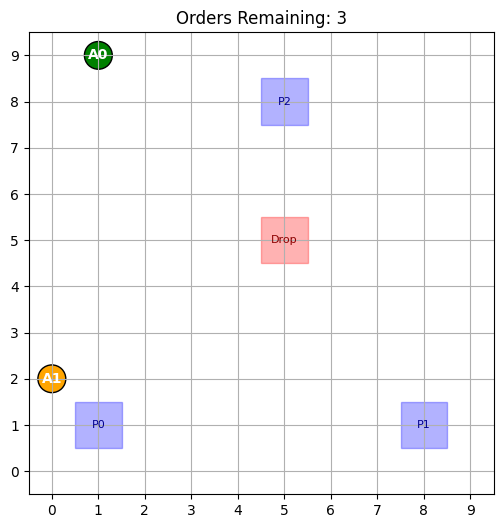

<Figure size 640x480 with 0 Axes>

テスト終了（時間切れ）。総報酬: -40.00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Dict, Tuple, List
import time
from IPython import display # Jupyter環境用（オプション）

# ----------------------------------------------------
# 0. 環境設定とWarehouseEnvクラス
# ----------------------------------------------------

# 環境設定
GRID_SIZE = 10
NUM_AGENTS = 2
NUM_ORDERS = 3
PICKUP_LOCATIONS = [(1, 1), (8, 1), (5, 8)] # オーダーID 0, 1, 2に対応
DROPOFF_LOCATION = (5, 5)

class WarehouseEnv:
    def __init__(self, size: int = GRID_SIZE, num_agents: int = NUM_AGENTS):
        self.size = size
        self.num_agents = num_agents
        self.action_space = 5 # 0:待機, 1:上, 2:下, 3:左, 4:右

        # Matplotlib用の図の保持
        self.fig = None
        self.ax = None

        # 状態の初期化
        self.reset()

    def reset(self) -> Dict[int, Tuple]:
        """環境を初期化し、初期状態を返します。"""
        self.agent_positions: Dict[int, Tuple[int, int]] = {
            i: (random.randint(0, self.size - 1), random.randint(0, self.size - 1))
            for i in range(self.num_agents)
        }
        self.agent_holding: Dict[int, bool] = {i: False for i in range(self.num_agents)}
        self.remaining_orders: List[int] = list(range(NUM_ORDERS))
        return self._get_obs()

    def _get_obs(self) -> Dict[int, Tuple]:
        obs = {}
        for i in range(self.num_agents):
            # 状態: (位置, 荷物有無, 残りオーダーIDタプル)
            obs[i] = (
                self.agent_positions[i],
                self.agent_holding[i],
                tuple(self.remaining_orders)
            )
        return obs

    def step(self, actions: Dict[int, int]) -> Tuple[Dict, Dict, Dict, Dict]:
        next_positions: Dict[int, Tuple[int, int]] = {}
        # チーム報酬 (協調タスクなので、報酬は各エージェントで共通であるべきですが、ここでは個別に計算し、QMIXの学習時に合計します)
        rewards: Dict[int, float] = {i: -0.1 for i in range(self.num_agents)} # 移動コスト/時間コスト

        # 1. 位置の更新
        for i, action in actions.items():
            current_x, current_y = self.agent_positions[i]
            next_x, next_y = current_x, current_y

            if action == 1: next_y += 1 # 上
            elif action == 2: next_y -= 1 # 下
            elif action == 3: next_x -= 1 # 左
            elif action == 4: next_x += 1 # 右

            next_x = np.clip(next_x, 0, self.size - 1)
            next_y = np.clip(next_y, 0, self.size - 1)
            next_positions[i] = (next_x, next_y)

        # 2. 衝突判定 (移動先が同じ場合は移動をキャンセルし、ペナルティ)
        final_positions = self.agent_positions.copy()
        is_collision = False

        for i in range(self.num_agents):
            pos = next_positions[i]
            is_colliding = False
            for j in range(self.num_agents):
                if i != j and pos == next_positions[j]:
                    is_colliding = True
                    break

            if is_colliding:
                rewards[i] -= 5.0 # 衝突ペナルティ (個別の報酬として計上)
                is_collision = True
            else:
                final_positions[i] = pos

        self.agent_positions = final_positions

        # 3. ピックアップ・ドロップオフ
        # 重要な点は、remaining_ordersが変更された場合、それが即座に反映されることです

        # ドロップオフが発生した場合の報酬を保持
        dropoff_reward = 0.0

        for i in range(self.num_agents):
            current_pos = self.agent_positions[i]

            if self.agent_holding[i]:
                # ドロップオフ判定
                if current_pos == DROPOFF_LOCATION:
                    self.agent_holding[i] = False
                    dropoff_reward += 50.0 # 大きな共同報酬

            else:
                # ピックアップ判定
                pickup_found = False
                for order_idx in self.remaining_orders:
                    if current_pos == PICKUP_LOCATIONS[order_idx]:
                        # オーダーIDをremaining_ordersから削除する（即時反映）
                        self.remaining_orders.remove(order_idx)
                        self.agent_holding[i] = True
                        rewards[i] += 10.0 # ピックアップ報酬 (個別の報酬)
                        pickup_found = True
                        break

        # QMIXは協調タスクであるため、ドロップオフ成功の大きな報酬は全エージェントで共有されるべき
        if dropoff_reward > 0.0:
            for i in range(self.num_agents):
                rewards[i] += dropoff_reward / self.num_agents # 各エージェントに分配 (合計は50.0)

        # 終了判定
        done = {i: len(self.remaining_orders) == 0 for i in range(self.num_agents)}
        return self._get_obs(), rewards, done, {"collision": is_collision}

    def render(self, mode='graphic', sleep_time=0.5):
        """環境を可視化します。"""
        if mode == 'text':
            self._render_text()
        elif mode == 'graphic':
            self._render_graphic(sleep_time)

    def _render_text(self):
        # ... (元のテキスト描画ロジック - 割愛) ...
        pass

    def _render_graphic(self, sleep_time):
        if self.fig is None:
            plt.ion() # インタラクティブモードON
            self.fig, self.ax = plt.subplots(figsize=(6, 6))

        self.ax.clear()
        self.ax.set_xlim(-0.5, self.size - 0.5)
        self.ax.set_ylim(-0.5, self.size - 0.5)
        self.ax.set_xticks(range(self.size))
        self.ax.set_yticks(range(self.size))
        self.ax.grid(True)
        self.ax.set_title(f"Orders Remaining: {len(self.remaining_orders)}")

        # ドロップオフ地点 (赤色)
        dx, dy = DROPOFF_LOCATION
        self.ax.add_patch(patches.Rectangle((dx-0.5, dy-0.5), 1, 1, color='red', alpha=0.3, label='Dropoff'))
        self.ax.text(dx, dy, 'Drop', ha='center', va='center', fontsize=8, color='darkred')

        # ピックアップ地点 (青色)
        for idx in range(NUM_ORDERS): # 全てのピックアップ地点を描画
            px, py = PICKUP_LOCATIONS[idx]
            color = 'blue'
            alpha = 0.3
            text = f'P{idx}'
            if idx not in self.remaining_orders:
                color = 'gray' # 完了したオーダーは灰色
                alpha = 0.1
                text = 'Done'

            self.ax.add_patch(patches.Rectangle((px-0.5, py-0.5), 1, 1, color=color, alpha=alpha, label='Pickup'))
            self.ax.text(px, py, text, ha='center', va='center', fontsize=8, color='darkblue' if idx in self.remaining_orders else 'gray')

        # エージェント (円)
        colors = ['green', 'orange', 'purple', 'cyan']
        for i, pos in self.agent_positions.items():
            ax, ay = pos
            color = colors[i % len(colors)]
            edgecolor = 'black'
            linewidth = 1
            if self.agent_holding[i]:
                linewidth = 3
                edgecolor = 'red' # 荷物持ち強調

            circle = patches.Circle((ax, ay), 0.3, facecolor=color, edgecolor=edgecolor, linewidth=linewidth, label=f'Agent {i}')
            self.ax.add_patch(circle)
            self.ax.text(ax, ay, f'A{i}', ha='center', va='center', color='white', fontweight='bold')

        plt.draw()
        try:
             # Jupyter/Colab 環境での描画更新
            display.clear_output(wait=True)
            display.display(self.fig)
        except:
            # ローカル環境での描画更新
            pass
        plt.pause(sleep_time)


# ----------------------------------------------------
# 1. ハイパーパラメータとネットワーク定義 (QMIXに必要な要素)
# ----------------------------------------------------

# --- ハイパーパラメータ ---
BATCH_SIZE = 64
GAMMA = 0.99
EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY = 5000
TARGET_UPDATE = 100
LR_AGENT = 0.0005
LR_MIXER = 0.001
MEMORY_SIZE = 50000
NUM_EPISODES = 10000
MAX_STEPS = 200

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- AgentNet ---

class AgentNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(AgentNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# --- QMixer (モノトニック制約付き) ---

class QMixer(nn.Module):
    def __init__(self, num_agents, state_dim, hidden_dim):
        super(QMixer, self).__init__()
        self.num_agents = num_agents
        self.state_dim = state_dim

        self.hyper_w1 = nn.Linear(state_dim, hidden_dim * num_agents)
        self.hyper_b1 = nn.Linear(state_dim, hidden_dim)

        self.hyper_w2 = nn.Linear(state_dim, hidden_dim)
        self.hyper_b2 = nn.Linear(state_dim, 1)

        self.hidden_dim = hidden_dim

    def forward(self, agent_qs, states):
        batch_size = agent_qs.size(0)

        # W1 の計算 (非負の重み)
        w1 = torch.abs(self.hyper_w1(states))
        w1 = w1.view(batch_size, self.num_agents, self.hidden_dim)

        # Q * W1 の計算
        agent_qs = agent_qs.view(batch_size, self.num_agents, 1)
        hidden = torch.bmm(agent_qs.transpose(1, 2), w1) # (B, 1, N) x (B, N, H) -> (B, 1, H)

        # B1 の計算
        b1 = self.hyper_b1(states)
        b1 = b1.view(batch_size, 1, self.hidden_dim)

        hidden = F.relu(hidden + b1) # (B, 1, H)

        # W2 の計算 (非負の重み)
        w2 = torch.abs(self.hyper_w2(states))
        w2 = w2.view(batch_size, self.hidden_dim, 1)

        # Q_tot の計算
        q_tot = torch.bmm(hidden, w2) # (B, 1, H) x (B, H, 1) -> (B, 1, 1)

        b2 = self.hyper_b2(states)
        b2 = b2.view(batch_size, 1, 1)

        q_tot = q_tot.view(batch_size, 1) + b2.view(batch_size, 1)

        return q_tot.squeeze(-1) # (B,)


# ----------------------------------------------------
# 2. Replay Memory
# ----------------------------------------------------

class QMixReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, next_state, reward, done):
        self.memory.append((state, action, next_state, reward, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# ----------------------------------------------------
# 3. QMIXエージェントクラス
# ----------------------------------------------------

class QMixAgent:
    def __init__(self, env: 'WarehouseEnv', state_dim):
        self.env = env
        self.num_agents = env.num_agents
        self.action_space = env.action_space
        self.state_dim = state_dim

        # Policy Networks
        self.agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                         for _ in range(self.num_agents)])
        self.mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)

        # Target Networks
        self.target_agent_nets = nn.ModuleList([AgentNet(self._get_agent_input_dim(), self.action_space).to(device)
                                                for _ in range(self.num_agents)])
        self.target_mixer = QMixer(self.num_agents, self.state_dim, hidden_dim=32).to(device)
        self.update_target_networks()

        # Optimizers
        # AgentNet と QMixer の最適化を分ける
        self.optimizer_agents = optim.Adam(self._get_agent_params(), lr=LR_AGENT)
        self.optimizer_mixer = optim.Adam(self.mixer.parameters(), lr=LR_MIXER)

        self.memory = QMixReplayMemory(MEMORY_SIZE)
        self.steps_done = 0

    def _get_agent_input_dim(self):
        # ローカル入力次元: 位置(2) + 荷物有無(1) + 全オーダーのマスク(NUM_ORDERS)
        return 2 + 1 + NUM_ORDERS # 2 + 1 + 3 = 6

    def _get_agent_params(self):
        params = []
        for net in self.agent_nets:
            params.extend(list(net.parameters()))
        return params

    def preprocess_state(self, obs: Dict[int, Tuple]):
        """
        環境の状態 (タプル) を学習可能なTensorに変換
        グローバル状態 (ミキサー用) とローカル状態 (エージェントネット用) を作成
        """
        # グローバル状態 (Global State): 全エージェントの位置、荷物有無、残りオーダー
        global_state = []
        for i in range(self.num_agents):
            (px, py), holding, _ = obs[i]
            # 座標の正規化
            global_state.extend([px / (self.env.size - 1), py / (self.env.size - 1), float(holding)])

        # 残りオーダー (ビットマスクをフラグに変換)
        order_mask = [0.0] * NUM_ORDERS
        remaining_order_ids = obs[0][2]
        for order_id in remaining_order_ids:
            order_mask[order_id] = 1.0
        global_state.extend(order_mask)

        # 状態次元のチェック
        if len(global_state) != self.state_dim:
             raise ValueError(f"State dimension mismatch: Expected {self.state_dim}, got {len(global_state)}")

        global_state_tensor = torch.tensor([global_state], dtype=torch.float32, device=device)

        # ローカル状態 (Agent State)
        local_states = []
        for i in range(self.num_agents):
            (px, py), holding, _ = obs[i]

            # ローカル入力 (位置, 荷物, オーダーマスク)
            local_input = [px / (self.env.size - 1), py / (self.env.size - 1), float(holding)]
            local_input.extend(order_mask) # グローバルなオーダー情報をローカル入力に含める

            local_states.append(torch.tensor([local_input], dtype=torch.float32, device=device))

        return global_state_tensor, local_states

    def select_action(self, global_state_tensor, local_states: List[torch.Tensor]):
        """ε-greedy法に基づく行動選択"""
        sample = random.random()
        eps_threshold = EPS_END + (EPS_START - EPS_END) * \
            np.exp(-1. * self.steps_done / EPS_DECAY)
        self.steps_done += 1

        actions = {}
        if sample > eps_threshold:
            with torch.no_grad():
                for i in range(self.num_agents):
                    q_values = self.agent_nets[i](local_states[i])
                    action = q_values.max(1)[1].item()
                    actions[i] = action
        else:
            actions = {i: random.randrange(self.action_space) for i in range(self.num_agents)}

        return actions

    def optimize_model(self):
        if len(self.memory) < BATCH_SIZE:
            return 0.0

        transitions = self.memory.sample(BATCH_SIZE)

        # 1. バッチデータの処理とTensor化
        batch_global_state = []
        batch_local_states = [[] for _ in range(self.num_agents)]
        batch_next_global_state = []
        batch_actions = []
        batch_rewards = []
        batch_done = []

        for state_dict, action_dict, next_state_dict, reward_dict, done_bool in transitions:
            global_state, local_states = self.preprocess_state(state_dict)
            next_global_state, next_local_states = self.preprocess_state(next_state_dict)

            batch_global_state.append(global_state.squeeze(0))
            batch_next_global_state.append(next_global_state.squeeze(0))

            for i in range(self.num_agents):
                # preprocess_stateの出力がローカル状態のテンソルのリストなので、バッチ作成時にその中身を抽出
                batch_local_states[i].append(local_states[i].squeeze(0))

            batch_actions.append([action_dict[i] for i in range(self.num_agents)])
            # QMIXではチーム報酬 (Total reward) を使用
            batch_rewards.append(sum(reward_dict.values()))
            batch_done.append(float(all(done_bool.values()) if isinstance(done_bool, Dict) else done_bool)) # doneは辞書またはbool

        global_state_batch = torch.stack(batch_global_state).to(device)
        next_global_state_batch = torch.stack(batch_next_global_state).to(device)
        local_states_batch = [torch.stack(l).to(device) for l in batch_local_states]

        action_batch = torch.tensor(batch_actions, dtype=torch.long, device=device)
        reward_batch = torch.tensor(batch_rewards, dtype=torch.float32, device=device).unsqueeze(1)
        done_batch = torch.tensor(batch_done, dtype=torch.float32, device=device).unsqueeze(1)

        # 2. Q(s, a) の計算 (Policy Net)
        q_values_list = []
        for i in range(self.num_agents):
            q_all = self.agent_nets[i](local_states_batch[i])
            q_selected = q_all.gather(1, action_batch[:, i].unsqueeze(1))
            q_values_list.append(q_selected)

        q_selected_agents = torch.stack(q_values_list, dim=1)
        q_tot = self.mixer(q_selected_agents, global_state_batch).unsqueeze(1)

        # 3. ターゲット値の計算 (Target Net)
        target_q_values_list = []
        with torch.no_grad():
            next_local_states = [
                self.preprocess_state(next_state_dict)[1][i]
                for _, _, next_state_dict, _, _ in transitions
            ]
            next_local_states_batch = [torch.stack(l).to(device) for l in batch_local_states] # この行は冗長だが、形状確保のため残す

            # next_local_states_batch の再構築 (このブロック内では、トランジションのループの外で next_local_states を効率的にバッチ化する方が良い)
            # 実際には、ステップ 1 で next_local_states_batch を作成済み

            for i in range(self.num_agents):
                target_q_all = self.target_agent_nets[i](next_local_states_batch[i])
                target_q_values_list.append(target_q_all)

        # Max Q'の選択 (貪欲な行動)
        target_q_selected_agents = torch.stack([q.max(1)[0].detach().unsqueeze(1)
                                                 for q in target_q_values_list], dim=1)

        with torch.no_grad():
            q_next_tot = self.target_mixer(target_q_selected_agents, next_global_state_batch).unsqueeze(1)

        expected_q_tot = reward_batch + GAMMA * q_next_tot * (1 - done_batch)

        # 4. 損失計算と最適化
        criterion = nn.SmoothL1Loss()
        loss = criterion(q_tot, expected_q_tot)

        self.optimizer_agents.zero_grad()
        self.optimizer_mixer.zero_grad()
        loss.backward()

        # 勾配クリッピング
        # ... (勾配クリッピング処理は省略せずに残します) ...
        for param in self._get_agent_params():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)
        for param in self.mixer.parameters():
            if param.grad is not None:
                param.grad.data.clamp_(-1, 1)

        self.optimizer_agents.step()
        self.optimizer_mixer.step()

        return loss.item()

    def update_target_networks(self):
        for policy_net, target_net in zip(self.agent_nets, self.target_agent_nets):
            target_net.load_state_dict(policy_net.state_dict())
        self.target_mixer.load_state_dict(self.mixer.state_dict())

    def save_model(self, path: str):
        """
        Policy Agent NetsとQMixerの状態をファイルに保存する。
        """
        # 保存する全てのネットワークの状態を一つの辞書にまとめる
        state_dicts = {
            f'agent_{i}': net.state_dict() for i, net in enumerate(self.agent_nets)
        }
        state_dicts['mixer'] = self.mixer.state_dict()

        # ファイルに保存
        torch.save(state_dicts, path)
        print(f"✅ モデルの状態を {path} に保存しました。")

    def load_model(self, path: str, target_nets: bool = True):
        """
        ファイルからPolicy Agent NetsとQMixerの状態をロードする。
        target_nets=Trueの場合、ロード後ターゲットネットワークも更新する。
        """
        state_dicts = torch.load(path, map_location=device)

        # Policy Agent Netsのロード
        for i in range(self.num_agents):
            self.agent_nets[i].load_state_dict(state_dicts[f'agent_{i}'])

        # QMixerのロード
        self.mixer.load_state_dict(state_dicts['mixer'])

        if target_nets:
            self.update_target_networks()

        print(f"✅ モデルの状態を {path} からロードしました。")

# ----------------------------------------------------
# 4. 学習ループ
# ----------------------------------------------------
# モデル保存用の定数を定義 (ここでは仮にファイルパスとして定義)
CHECKPOINT_INTERVAL = 1000 # チェックポイント保存間隔 (エピソード数)
CHECKPOINT_PATH = 'qmix_checkpoint_ep{}.pth' # チェックポイントファイル名テンプレート
BEST_MODEL_PATH = 'qmix_best_model.pth' # ベストモデルファイル名

def train_qmix_agent(env: 'WarehouseEnv'):

    # グローバル状態の次元を正確に計算: 2*N (位置) + N (荷物有無) + NUM_ORDERS (オーダーマスク)
    state_dim = 2 * env.num_agents + env.num_agents + NUM_ORDERS # 2*2 + 2 + 3 = 9
    agent = QMixAgent(env, state_dim=state_dim)

    rewards_history = []
    best_avg_reward = -float('inf') # ベストモデル保存用の初期値

    print("--- QMIX 学習開始 ---")
    print(f"Global State Dimension (state_dim): {state_dim}")
    print(f"Local Agent Input Dimension: {agent._get_agent_input_dim()}")

    for i_episode in range(NUM_EPISODES):
        obs = env.reset()
        global_state, local_states = agent.preprocess_state(obs)

        episode_reward = 0

        for t in range(MAX_STEPS):
            actions = agent.select_action(global_state, local_states)
            next_obs, rewards, done, info = env.step(actions)

            # doneはディクショナリであるため、all(done.values())で全体終了を判断
            agent.memory.push(obs, actions, next_obs, rewards, all(done.values()))

            obs = next_obs
            global_state, local_states = agent.preprocess_state(obs)
            episode_reward += sum(rewards.values())

            loss = agent.optimize_model()

            if all(done.values()):
                break

        rewards_history.append(episode_reward)

        if (i_episode + 1) % TARGET_UPDATE == 0:
            agent.update_target_networks()

        if (i_episode + 1) % 100 == 0:
            avg_reward = np.mean(rewards_history[-100:])
            print(f"Episode {i_episode+1}/{NUM_EPISODES} | Avg Reward (100): {avg_reward:.2f} | Steps: {t+1} | Epsilon: {EPS_END + (EPS_START - EPS_END) * np.exp(-1. * agent.steps_done / EPS_DECAY):.4f}")

            # 💡 ベストモデルの保存
            if avg_reward > best_avg_reward:
                best_avg_reward = avg_reward
                agent.save_model(BEST_MODEL_PATH)
                print(f"🏆 新しいベストモデルを {BEST_MODEL_PATH} に保存しました (Avg Reward: {best_avg_reward:.2f})")

        # 💡 定期的なチェックポイントの保存
        if (i_episode + 1) % CHECKPOINT_INTERVAL == 0:
            checkpoint_file = CHECKPOINT_PATH.format(i_episode + 1)
            agent.save_model(checkpoint_file)
            print(f"💾 チェックポイントを {checkpoint_file} に保存しました。")

    print("\n✅ 学習完了")

    # 最終モデルの保存 (ベストモデルと重複する可能性はあるが、完了したことを示す)
    agent.save_model("qmix_final_model.pth")
    return agent, rewards_history


# ----------------------------------------------------
# 5. 実行とテスト
# ----------------------------------------------------

if __name__ == "__main__":
    env = WarehouseEnv(size=GRID_SIZE, num_agents=NUM_AGENTS)

    # 学習の実行
    trained_agent, rewards = train_qmix_agent(env)

    # 学習曲線の表示
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title("QMIX Total Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.show()

    # --- 学習済みモデルでのテスト実行 ---
    print("\n--- テスト実行 (可視化) ---")
    obs = env.reset()
    trained_agent.agent_nets.eval() # 評価モード

    total_test_reward = 0

    for t in range(MAX_STEPS):
        global_state, local_states = trained_agent.preprocess_state(obs)

        # ε=0 (貪欲) で行動を選択
        actions = {}
        with torch.no_grad():
            for i in range(env.num_agents):
                q_values = trained_agent.agent_nets[i](local_states[i])
                action = q_values.max(1)[1].item()
                actions[i] = action

        next_obs, rewards, done, info = env.step(actions)
        total_test_reward += sum(rewards.values())

        # 可視化
        env.render(mode='graphic', sleep_time=0.1)

        obs = next_obs

        if all(done.values()):
            print(f"テスト完了！ 全てのタスクを {t+1} ステップで完了しました。総報酬: {total_test_reward:.2f}")
            plt.pause(2.0)
            break

    if not all(done.values()):
        print(f"テスト終了（時間切れ）。総報酬: {total_test_reward:.2f}")

    plt.ioff()
    plt.show()

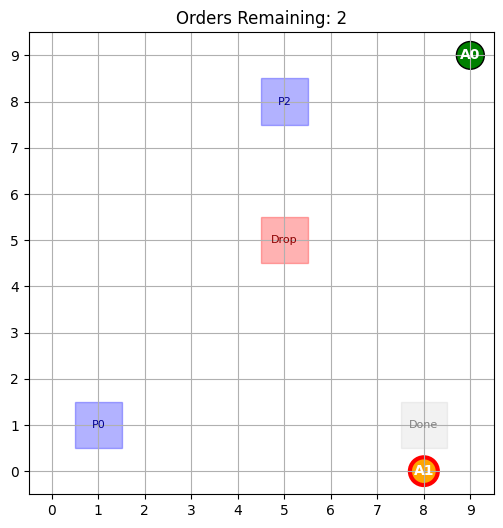

<Figure size 640x480 with 0 Axes>

In [ ]:
# --- 学習済みモデルでのテスト実行 ---
print("\n--- テスト実行 (可視化) ---")
obs = env.reset()
trained_agent.agent_nets.eval() # 評価モード

total_test_reward = 0

for t in range(MAX_STEPS):
    global_state, local_states = trained_agent.preprocess_state(obs)

    # ε=0 (貪欲) で行動を選択
    actions = {}
    with torch.no_grad():
        for i in range(env.num_agents):
            q_values = trained_agent.agent_nets[i](local_states[i])
            action = q_values.max(1)[1].item()
            actions[i] = action

    next_obs, rewards, done, info = env.step(actions)
    total_test_reward += sum(rewards.values())

    # 可視化
    env.render(mode='graphic', sleep_time=0.1)

    obs = next_obs

    if all(done.values()):
        print(f"テスト完了！ 全てのタスクを {t+1} ステップで完了しました。総報酬: {total_test_reward:.2f}")
        plt.pause(2.0)
        break

if not all(done.values()):
    print(f"テスト終了（時間切れ）。総報酬: {total_test_reward:.2f}")

plt.ioff()
plt.show()